# Flow matching for dynamic CRL with soft interventions

In [1]:
from dataclasses import dataclass, field
from typing import Optional, Tuple

import numpy as np
import pandas as pd
import torch
from IPython.display import display

from utils import set_seed
from sim import simulate_experiment_data
from particles import GraphSpace
from fm import FMMetadata
from train import run_stage0, run_stage1, run_oracle_representation_diagnostic
from diagnostics import *


## 1. Experiment and training settings

In [2]:
def best_available_device() -> str:
    return "cuda" if torch.cuda.is_available() else "cpu"


@dataclass
class ExperimentConfig:
    # Reproducibility / runtime
    SEED: int = 13
    DEVICE: str = field(default_factory=best_available_device)

    # Data / simulation
    N: int = 300
    TRAIN_L: int = 90
    TEST_L: int = 90
    N_TEST: int = 80
    P: int = 40
    A: int = 3
    K_DATA: int = 2
    K_FIT: int = 2
    VAL_FRAC: float = 0.25

    # Observation model: unchanged
    OBS_NONLINEAR_STRENGTH: float = 0.10
    OBS_NOISE_SD: float = 0.03

    # Stage 0: observation compressor
    CONTEXT_TOKENS: int = 4
    CONTEXT_WIDTH: int = 64
    CONTEXT_LAYERS: int = 2
    CONTEXT_HEADS: int = 4
    CONTEXT_LR: float = 1e-3
    CONTEXT_STEPS: int = 1000
    CONTEXT_BATCH: int = 32
    CONTEXT_MIN_LENGTH: Optional[int] = None

    # Stage 1, Block 1: representation and moving graph particles
    MAX_OUTER: int = 200
    LR_REP: float = 1e-4
    LR_MILESTONES: Tuple[int, ...] = ()
    LR_GAMMA: float = 1.0
    RECON_SIGMA: float = 0.20
    BETA_STRUCT: float = 0.20
    ENCODER_RESIDUAL_STRENGTH: float = 0.02
    REP_UPDATES_PER_OUTER: int = 10
    REP_BATCH_TRAJ: int = 64

    RIDGE: float = 1e-3

    RESP_TEMP: float = 1.0
    PI_ALPHA: float = 1.0
    RESP_FLOOR: float = 1e-4
    MIN_EFFECTIVE_N: float = 12.0
    DEAD_PATIENCE: int = 3

    GRAPH_MOVES_PER_OUTER: int = 3
    TAU_GRAPH: float = 5e-4

    # Soft-intervention graph selector
    SOFT_GRAPH_BURNIN: int = 1
    SOFT_GRAPH_POLY_DEGREE: int = 3
    SOFT_GRAPH_EDGE_PENALTY: float = 0.002
    ETA_H: float = 0.65
    TAU_H: float = 0.60
    TAU_LOGVAR: float = 0.02
    SELF_COEF_MAX: float = 0.95

    # Stage 1, Block 2: conditional graph/H FM
    FM_HIDDEN: int = 64
    FM_LR: float = 1e-4
    FM_UPDATES_PER_OUTER: int = 5
    FM_BATCH: int = 100
    FM_SIM_REPS_PER_COMPONENT_INTERVENTION: int = 50
    FM_SIM_LENGTHS: Tuple[int, ...] = field(default_factory=tuple)

    FM_GRAPH_EPS: float = 0.02
    FM_LAMBDA_LAG: float = 1.0
    FM_LAMBDA_INST: float = 1.0
    FM_LAMBDA_H: float = 1.0

    H_COEF_SCALE: float = 1.0
    H_LOGVAR_SCALE: float = 3.0

    FM_GEN_STEPS: int = 100
    FM_ETA: float = 0.0
    FM_SAMPLES_PER_TEST: int = 3

    PARTICLE_PLOT_BURNIN: int = 20

    def __post_init__(self) -> None:
        if self.CONTEXT_MIN_LENGTH is None:
            self.CONTEXT_MIN_LENGTH = max(20, self.TRAIN_L // 2)
        if not self.FM_SIM_LENGTHS:
            self.FM_SIM_LENGTHS = tuple(sorted({
                max(20, self.TRAIN_L // 2),
                self.TRAIN_L,
                int(round(1.5 * self.TRAIN_L)),
            }))
        if self.K_FIT < self.K_DATA:
            raise ValueError("K_FIT must be >= K_DATA")

    @property
    def CONTEXT_DIM(self) -> int:
        return self.CONTEXT_TOKENS * self.CONTEXT_WIDTH

    @property
    def D(self) -> int:
        return self.A

    @property
    def L(self) -> int:
        return self.TRAIN_L


cfg = ExperimentConfig()

## 2. Simulation

In [3]:
device = set_seed(cfg)

data = simulate_experiment_data(cfg, device)
graph_space = GraphSpace.build(cfg)
fm_metadata = FMMetadata.build(cfg, graph_space)

print("device:", device, "seed:", cfg.SEED)
print("train Y:", data.Y_np.shape, "test Y:", data.Y_test_np.shape)
print("train/validation trajectories:", len(data.train_idx), len(data.val_idx))
print("initial registered graph states:", len(graph_space.graph_pairs))
print("possible lag edges:", len(graph_space.lag_edge_list))
print("possible instantaneous pairs:", len(graph_space.inst_pair_list))
print("FM simulation lengths:", cfg.FM_SIM_LENGTHS)
print("context dimension:", cfg.CONTEXT_DIM)
print("H dimension:", fm_metadata.h_dim)
print("FM eta:", cfg.FM_ETA)


device: cuda seed: 13
train Y: (300, 90, 40) test Y: (80, 90, 40)
train/validation trajectories: 225 75
initial registered graph states: 1
possible lag edges: 6
possible instantaneous pairs: 3
FM simulation lengths: (45, 90, 135)
context dimension: 256
H dimension: 54
FM eta: 0.0


## 3. Stage 0 — train and freeze $C(Y,I)$

context step=0001 | reconstruction=1.21022
context step=0100 | reconstruction=0.10619
context step=0200 | reconstruction=0.12008
context step=0300 | reconstruction=0.11288
context step=0400 | reconstruction=0.10724
context step=0500 | reconstruction=0.10521
context step=0600 | reconstruction=0.10743
context step=0700 | reconstruction=0.10539
context step=0800 | reconstruction=0.10447
context step=0900 | reconstruction=0.11324
context step=1000 | reconstruction=0.10376
Stage-0 validation reconstruction MSE: 0.12504900991916656
frozen context dimension: 256


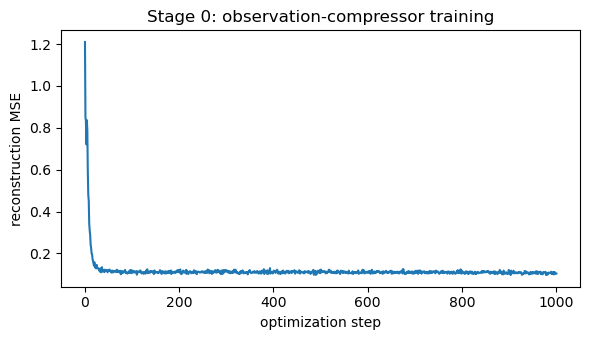

In [4]:
stage0 = run_stage0(cfg, data, verbose=True)
print("Stage-0 validation reconstruction MSE:", stage0["validation_mse"])
print("frozen context dimension:", cfg.CONTEXT_DIM)
plot_stage0_trace(stage0)

## 4. Stage 1 — representation, moving graph particles, and FM

At each outer iteration, the encoder is updated under the current graph particles, deterministic $H$ is refit, and regime responsibilities are refreshed. After the burn-in, the soft-intervention anchor is recomputed from the current learned $Z$ and $\gamma$. Each graph particle then makes local one-edge MH moves scored by the anchored cubic validation score. Only proposed parent sets are fit and cached; the full graph space is never enumerated.

The graph particles keep moving throughout training; there is no graph-freezing rule. $H$ perturbations are used only to augment FM training.


In [5]:
result = run_stage1(
    cfg,
    data,
    graph_space,
    fm_metadata,
    stage0["context_net"],
    verbose=True,
)

soft intervention anchor | orders=((0, 1, 2), (2, 1, 0)) | pairs=[2, 6] | accepted=5 | score=0.0124705
outer=01 | ARI=1.000 | pi=[0.56 0.44] | d=[[3, 7], [6, 6]] | G changes=2 | accepted=5 | FM=3.346
soft intervention anchor | orders=((0, 1, 2), (2, 1, 0)) | pairs=[7, 22] | accepted=1 | score=5.38276e-05
outer=05 | ARI=1.000 | pi=[0.56 0.44] | d=[[2, 8], [10, 2]] | G changes=1 | accepted=1 | FM=3.279
soft intervention anchor | orders=((0, 1, 2), (2, 1, 0)) | pairs=[32, 24] | accepted=1 | score=5.40972e-05
outer=10 | ARI=1.000 | pi=[0.56 0.44] | d=[[1, 9], [11, 1]] | G changes=1 | accepted=1 | FM=3.225
soft intervention anchor | orders=((0, 1, 2), (2, 1, 0)) | pairs=[38, 24] | accepted=0 | score=5.40405e-05
outer=15 | ARI=1.000 | pi=[0.56 0.44] | d=[[0, 10], [11, 1]] | G changes=0 | accepted=0 | FM=3.077
soft intervention anchor | orders=((0, 1, 2), (2, 1, 0)) | pairs=[38, 41] | accepted=1 | score=5.41035e-05
outer=20 | ARI=1.000 | pi=[0.56 0.44] | d=[[0, 10], [10, 0]] | G changes=1 | a

In [6]:
print("selected graph registry indices:", result["pairs"].tolist())
print("soft-intervention orders:", result["soft_graph_info"]["orders"])
print("order score:", result["soft_graph_info"]["order_score"])
print("registered graph states:", len(graph_space.graph_pairs))
print("true graph registry indices (diagnostic only):", graph_space.true_pair_indices(data))


selected graph registry indices: [43, 41]
soft-intervention orders: ((0, 1, 2), (2, 1, 0))
order score: 9.305310531391767e-05
registered graph states: 83
true graph registry indices (diagnostic only): [38, 41]


## 5. Block-1 diagnostics

,component,pi,effective N,graph pair index,distance to truth 1,distance to truth 2
0,1,0.559591,167.9964,43,1,9
1,2,0.440409,132.0036,41,10,0


,true z1,true z2,true z3
learned z1,-0.955602,-0.666921,0.285859
learned z2,0.196089,0.966518,-0.549357
learned z3,-0.370723,0.394647,-0.902708


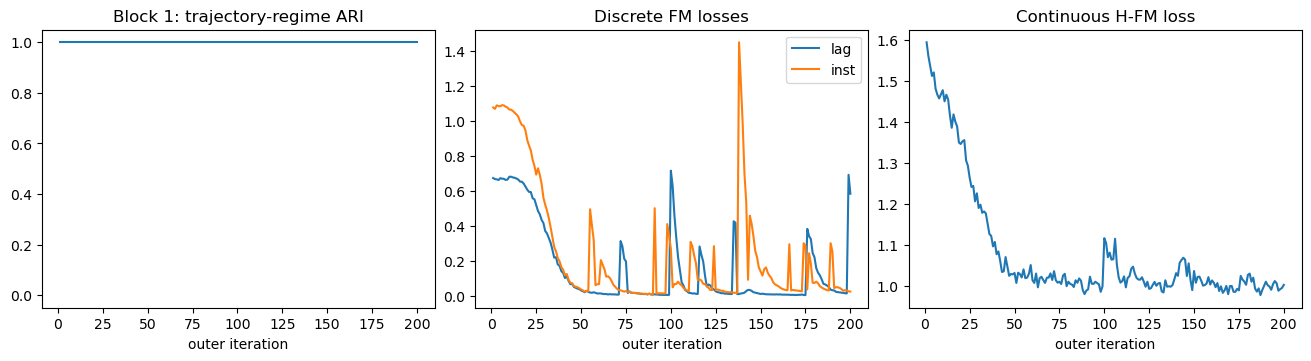

In [7]:
display(block1_summary(result, cfg, data, graph_space))
display(latent_correlation_table(result, cfg, data))
plot_training_trace(result)

## 6. Conditional FM diagnostics on held-out trajectories

,metric,value
0,test recording length,90.000000
1,DeFoG eta,0.000000
2,instantaneous DAG validity,1.000000
3,exact lag graph,0.883333
4,exact instantaneous graph,0.937500
5,exact joint graph pair,0.820833


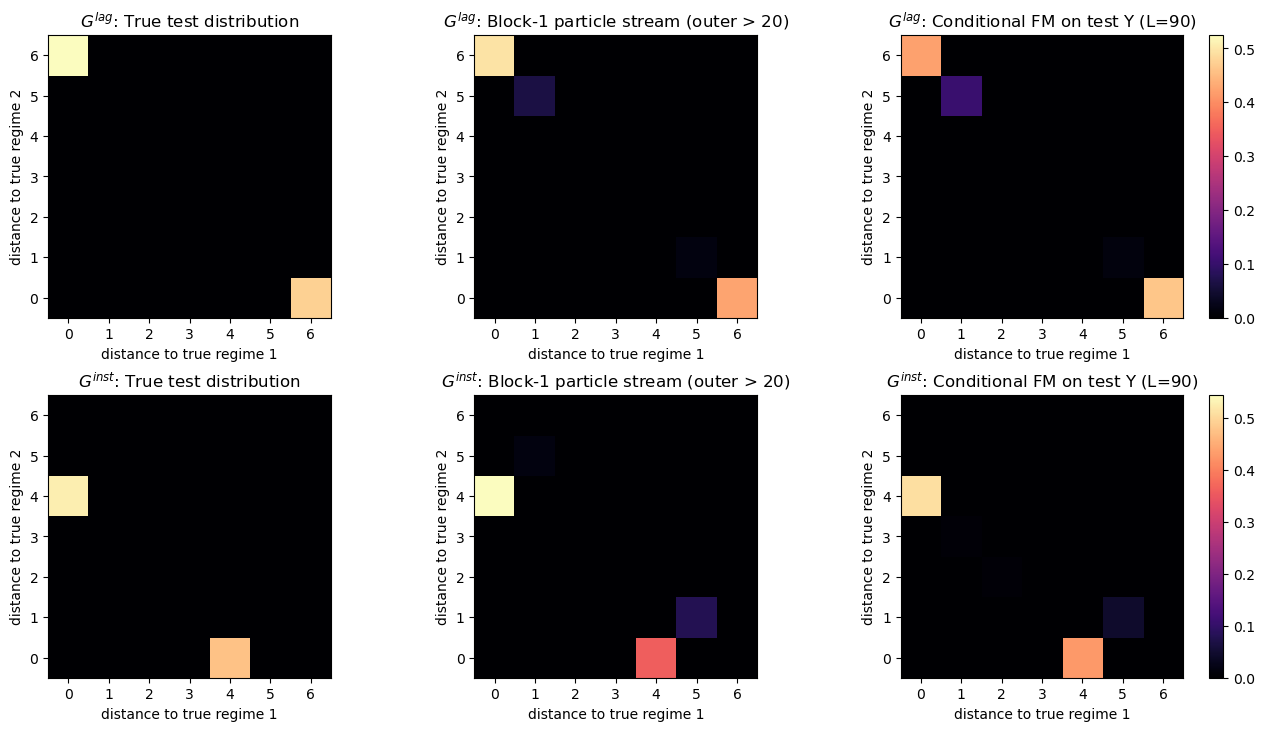

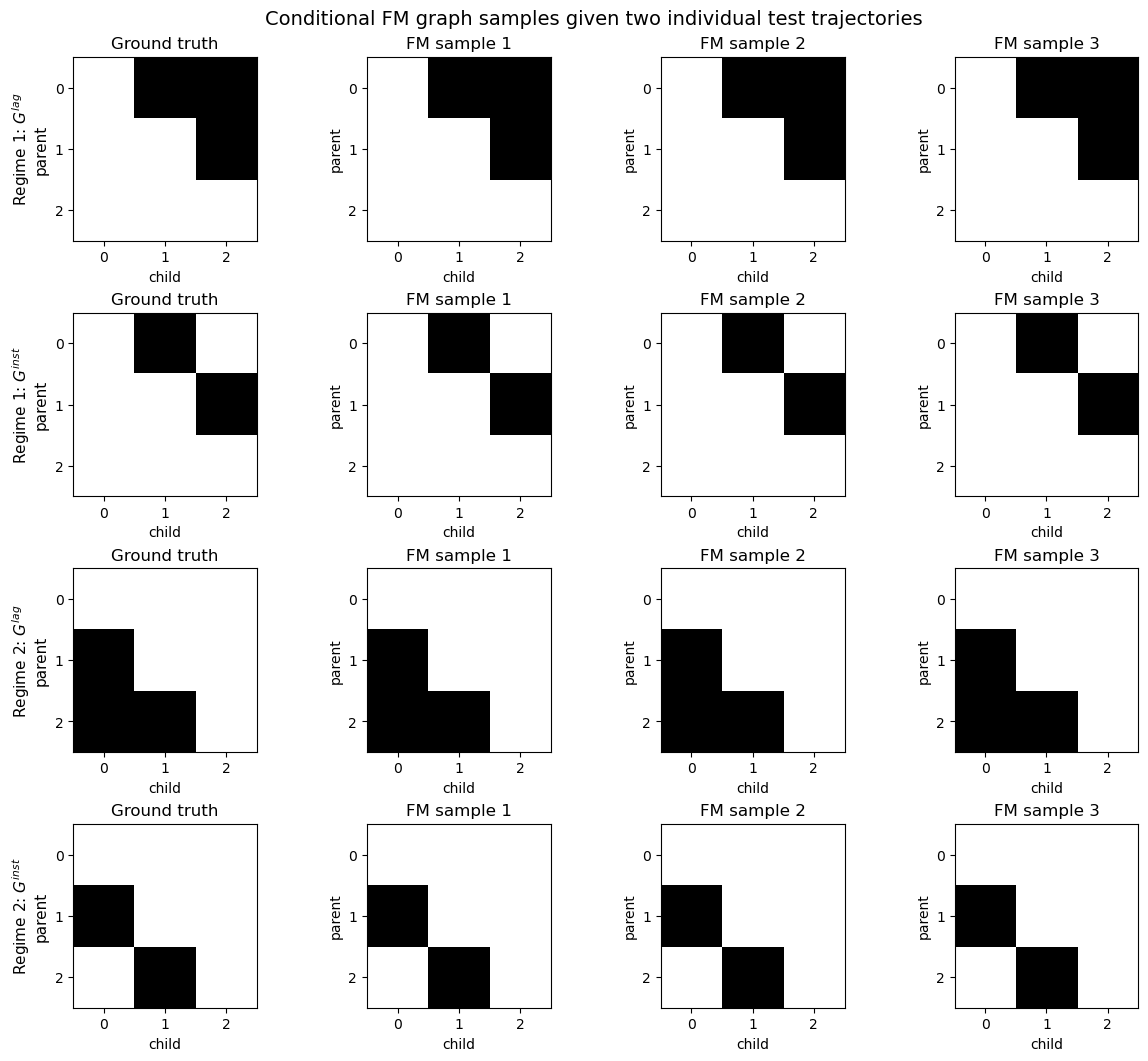

representative test indices: [2, 0]


In [8]:
posterior = evaluate_test_posterior(
    result,
    cfg,
    data,
    graph_space,
    fm_metadata,
)
display(posterior_metric_table(posterior, cfg))
plot_graph_distribution(result, posterior, cfg, data, graph_space)
chosen_test_indices = plot_representative_graph_samples(
    result,
    posterior,
    cfg,
    data,
    graph_space,
    fm_metadata,
    n_samples=cfg.FM_SAMPLES_PER_TEST,
)
print("representative test indices:", chosen_test_indices)

## 7. Mechanism diagnostics

The first diagnostic isolates the weighted-ridge estimator using true $Z$, true regime labels, and the true graph. The second follows the original repository and samples $H\mid Y,I,G_{\mathrm{true}}$ from the conditional FM.


Joint FM H RMSE (all coordinates): 1.290363521331699
Joint FM H RMSE (true-graph active coordinates): 1.2614211508008906


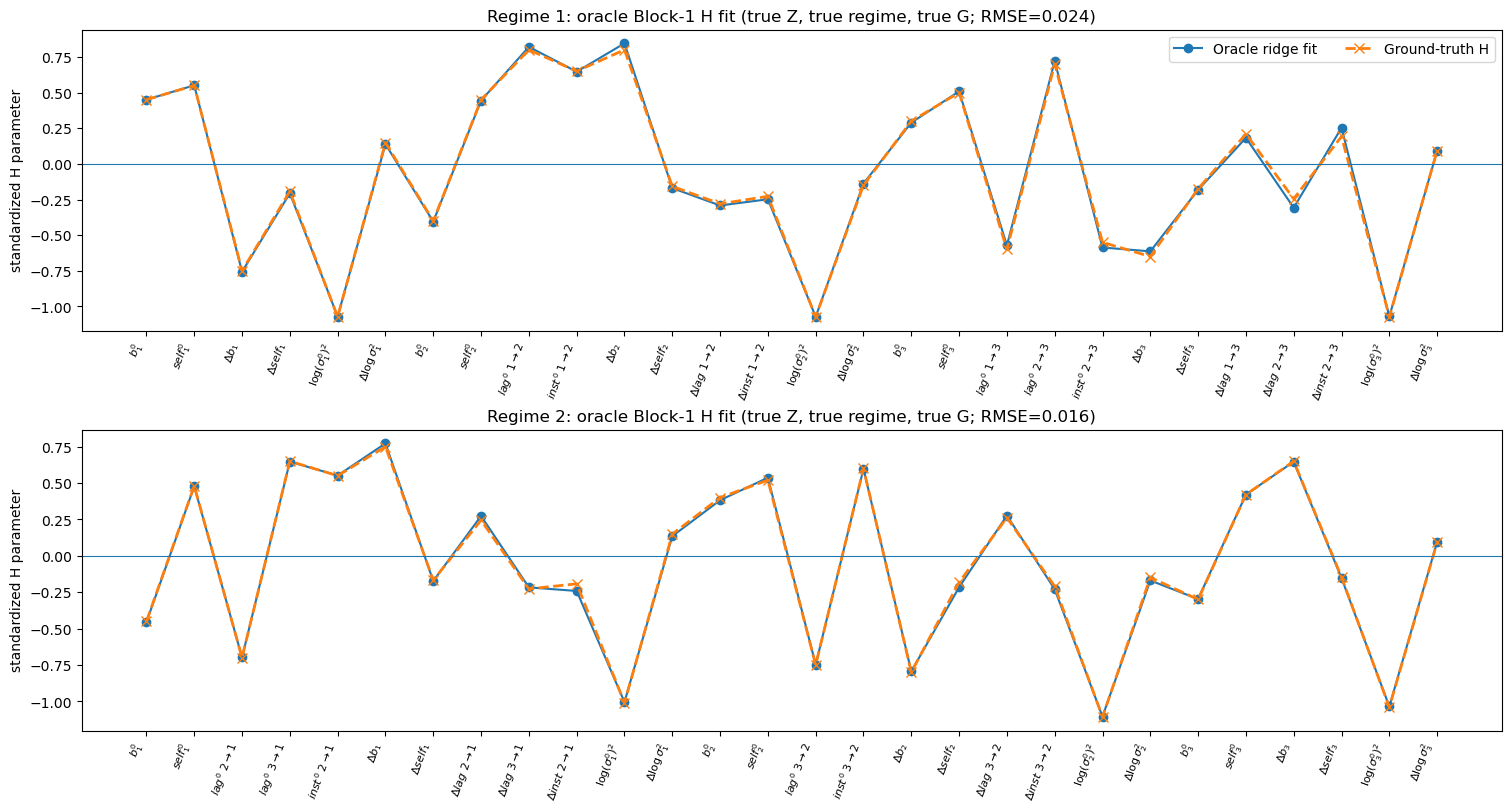

,true regime,true graph pair,active H dimensions,oracle ridge H RMSE
0,1,38,28,0.024082
1,2,41,28,0.015888


In [9]:
print(
    "Joint FM H RMSE (all coordinates):",
    h_rmse_to_truth(
        posterior,
        cfg,
        data,
        fm_metadata,
        active_only=False,
    ),
)
print(
    "Joint FM H RMSE (true-graph active coordinates):",
    h_rmse_to_truth(
        posterior,
        cfg,
        data,
        fm_metadata,
        active_only=True,
    ),
)

oracle_h_summary = plot_oracle_H_regression_diagnostics(
    cfg,
    data,
    graph_space,
    fm_metadata,
)
display(oracle_h_summary)


## 8. Conditional $H$ diagnostic with the true graph fixed


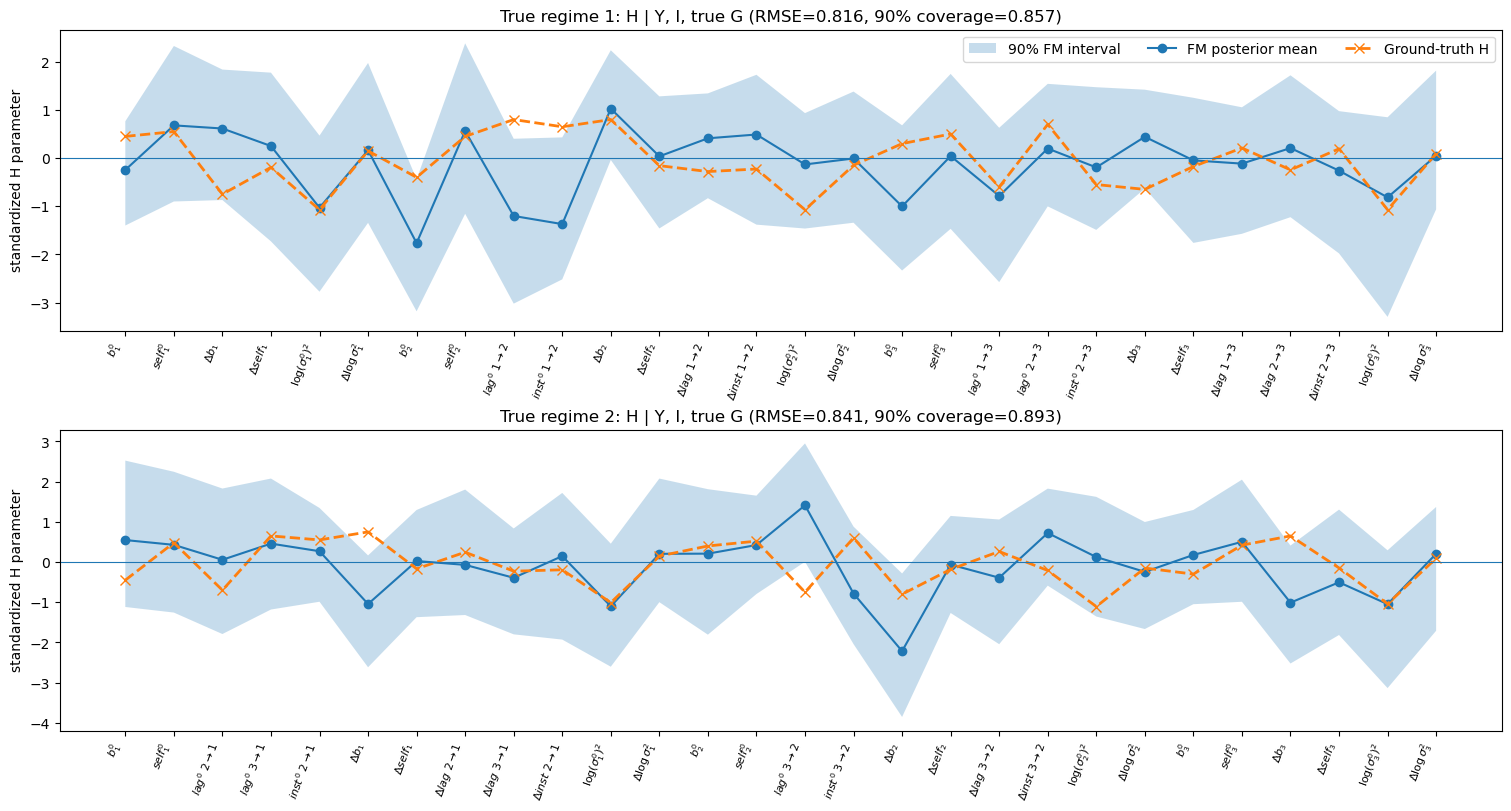

,true regime,test trajectory index,I,active H dimensions,posterior mean RMSE,90% interval coverage
0,1,2,"[0, 0, 1]",28,0.815583,0.857143
1,2,0,"[0, 0, 0]",28,0.840833,0.892857


In [10]:
h_summary = plot_h_diagnostics(
    result,
    posterior,
    chosen_test_indices,
    cfg,
    data,
    graph_space,
    fm_metadata,
    n_samples=30,
)
display(h_summary)


## 9. Oracle representation diagnostic — true $G$ and true regime labels

This diagnostic keeps the encoder/decoder objective unchanged but removes graph and regime uncertainty. The graph pair and regime responsibilities are fixed to truth, while $H$ is re-fit from the current learned $Z$ after every outer iteration. If $Z$ still stays mixed, the bottleneck is the representation objective/optimization rather than graph or clustering inference.


oracle-Z initial encoder gradients | reconstruction=4.703e-07 | beta*structural=0.2344 | ratio=4.984e+05
oracle-Z initial best |corr|=0.8851
oracle-Z outer=01 | best |corr|=0.8859 | latent RMS change=0.0056 | rec=0.1372 | struct=0.7343 | lr=1.00e-04
oracle-Z outer=05 | best |corr|=0.8883 | latent RMS change=0.0226 | rec=0.1382 | struct=0.7248 | lr=1.00e-04
oracle-Z outer=10 | best |corr|=0.8904 | latent RMS change=0.0394 | rec=0.1389 | struct=0.7157 | lr=1.00e-04
oracle-Z outer=15 | best |corr|=0.8921 | latent RMS change=0.0532 | rec=0.1384 | struct=0.7153 | lr=1.00e-04
oracle-Z outer=20 | best |corr|=0.8940 | latent RMS change=0.0684 | rec=0.1377 | struct=0.7192 | lr=1.00e-04
oracle-Z outer=25 | best |corr|=0.8957 | latent RMS change=0.0820 | rec=0.1382 | struct=0.6972 | lr=1.00e-04
oracle-Z outer=30 | best |corr|=0.8975 | latent RMS change=0.0972 | rec=0.1365 | struct=0.6945 | lr=1.00e-04
oracle-Z outer=35 | best |corr|=0.8994 | latent RMS change=0.1139 | rec=0.1367 | struct=0.6888 |

,true z1,true z2,true z3
learned z1,-0.749598,-0.856947,0.626797
learned z2,0.336689,0.943080,-0.279259
learned z3,0.008464,0.324440,-0.962733


Final latent correlation with true G and true regime labels:


,true z1,true z2,true z3
learned z1,-0.780322,-0.854657,0.579160
learned z2,0.321121,0.949483,-0.307859
learned z3,-0.029135,0.359920,-0.975044


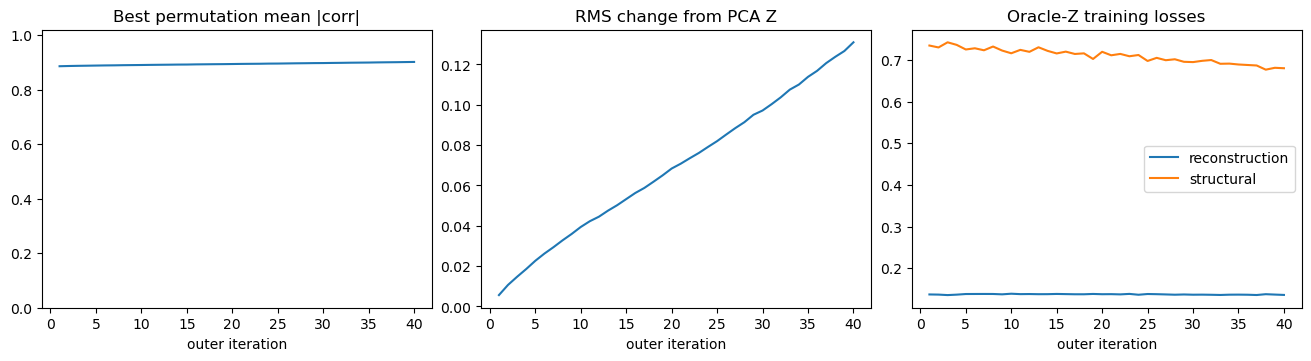

In [11]:
oracle_z = run_oracle_representation_diagnostic(
    cfg,
    data,
    graph_space,
    max_outer=40,
    verbose=True,
)

print("initial encoder gradient norms:", oracle_z["initial_gradient_norms"])
print("initial best mean |corr|:", oracle_z["initial_best_abs_corr"])
print("final best mean |corr|:", oracle_z["final_best_abs_corr"])
print("final latent RMS change from PCA:", oracle_z["final_latent_rms_change"])

print("Initial latent correlation:")
display(oracle_representation_correlation_table(oracle_z, cfg, data, initial=True))
print("Final latent correlation with true G and true regime labels:")
display(oracle_representation_correlation_table(oracle_z, cfg, data, initial=False))
plot_oracle_representation_trace(oracle_z)
